# 01 · Exploratory data analysis

What is in the data, and what does it mean for the models? Each section asks a question, shows the raw data first and ends with key findings.

Needs the Kaggle data in `../data/raw` (see `configs/paths.yaml`).

In [1]:
import pandas as pd

from rsna.paths import load_paths

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

paths = load_paths()
DATA_DIR = paths["raw_data_dir"]
assert DATA_DIR.exists(), f"data not found: {DATA_DIR}"

## 1. Data inventory

What did Kaggle give us? Top-level files and folders:

In [2]:
rows = []
for p in sorted(DATA_DIR.iterdir()):
    if p.is_dir():
        files = list(p.iterdir())
        size = sum(f.stat().st_size for f in files)
        rows.append({"name": p.name, "type": "folder", "n_files": len(files), "size_mb": size / 1e6})
    else:
        rows.append({"name": p.name, "type": "file", "n_files": None, "size_mb": p.stat().st_size / 1e6})

pd.DataFrame(rows).round(1)

,name,type,n_files,size_mb
0,stage_2_detailed_class_info.csv,file,NaN,1.6
1,stage_2_sample_submission.csv,file,NaN,0.2
2,stage_2_test_images,folder,3000.0,398.0
3,stage_2_train_images,folder,26684.0,3555.3
4,stage_2_train_labels.csv,file,NaN,1.5


Inside the image folders: file extensions, example names and file sizes.

In [3]:
for folder in ["stage_2_train_images", "stage_2_test_images"]:
    files = sorted((DATA_DIR / folder).iterdir())
    sizes_kb = pd.Series([f.stat().st_size / 1e3 for f in files])
    exts = pd.Series([f.suffix for f in files]).value_counts().to_dict()
    print(f"{folder}")
    print(f"  files      : {len(files):,}")
    print(f"  extensions : {exts}")
    print(f"  examples   : {[f.name for f in files[:3]]}")
    print(f"  size (KB)  : min {sizes_kb.min():.0f} | median {sizes_kb.median():.0f} | max {sizes_kb.max():.0f}")
    print()

stage_2_train_images
  files      : 26,684
  extensions : {'.dcm': 26684}
  examples   : ['0004cfab-14fd-4e49-80ba-63a80b6bddd6.dcm', '000924cf-0f8d-42bd-9158-1af53881a557.dcm', '000db696-cf54-4385-b10b-6b16fbb3f985.dcm']
  size (KB)  : min 46 | median 136 | max 371

stage_2_test_images
  files      : 3,000
  extensions : {'.dcm': 3000}
  examples   : ['0000a175-0e68-4ca4-b1af-167204a7e0bc.dcm', '0005d3cc-3c3f-40b9-93c3-46231c3eb813.dcm', '000686d7-f4fc-448d-97a0-44fa9c5d3aa6.dcm']
  size (KB)  : min 46 | median 135 | max 190



## 2. CSV files

Load the three CSVs and look at their structure.

In [4]:
labels = pd.read_csv(DATA_DIR / "stage_2_train_labels.csv")
classes = pd.read_csv(DATA_DIR / "stage_2_detailed_class_info.csv")
sample_sub = pd.read_csv(DATA_DIR / "stage_2_sample_submission.csv")

csvs = {"train_labels": labels, "detailed_class_info": classes, "sample_submission": sample_sub}

### 2.1 Raw tables

The first rows of each CSV, exactly as given. Everything else in this project is derived from these.

In [5]:
for name, df in csvs.items():
    print(f"{name}: {df.shape[0]:,} rows x {df.shape[1]} columns")
    display(df.head())

train_labels: 30,227 rows x 6 columns


,patientId,x,y,width,height,Target
0,0004cfab-14fd-4e49-80ba-63a80b6bddd6,NaN,NaN,NaN,NaN,0
1,00313ee0-9eaa-42f4-b0ab-c148ed3241cd,NaN,NaN,NaN,NaN,0
2,00322d4d-1c29-4943-afc9-b6754be640eb,NaN,NaN,NaN,NaN,0
3,003d8fa0-6bf1-40ed-b54c-ac657f8495c5,NaN,NaN,NaN,NaN,0
4,00436515-870c-4b36-a041-de91049b9ab4,264.0,152.0,213.0,379.0,1


detailed_class_info: 30,227 rows x 2 columns


,patientId,class
0,0004cfab-14fd-4e49-80ba-63a80b6bddd6,No Lung Opacity / Not Normal
1,00313ee0-9eaa-42f4-b0ab-c148ed3241cd,No Lung Opacity / Not Normal
2,00322d4d-1c29-4943-afc9-b6754be640eb,No Lung Opacity / Not Normal
3,003d8fa0-6bf1-40ed-b54c-ac657f8495c5,Normal
4,00436515-870c-4b36-a041-de91049b9ab4,Lung Opacity


sample_submission: 3,000 rows x 2 columns


,patientId,PredictionString
0,0000a175-0e68-4ca4-b1af-167204a7e0bc,0.5 0 0 100 100
1,0005d3cc-3c3f-40b9-93c3-46231c3eb813,0.5 0 0 100 100
2,000686d7-f4fc-448d-97a0-44fa9c5d3aa6,0.5 0 0 100 100
3,000e3a7d-c0ca-4349-bb26-5af2d8993c3d,0.5 0 0 100 100
4,00100a24-854d-423d-a092-edcf6179e061,0.5 0 0 100 100


### 2.2 Column types and categories

Columns with only a few distinct values are categorical; their categories are listed.

In [6]:
rows = []
for name, df in csvs.items():
    for col in df.columns:
        values = df[col].dropna().unique()
        rows.append({
            "csv": name,
            "column": col,
            "dtype": str(df[col].dtype),
            "categories": sorted(values.tolist()) if 2 <= len(values) <= 10 else "",
        })

pd.DataFrame(rows).set_index(["csv", "column"])

dtype                                         categories
csv                 column                                                                      
train_labels        patientId             str                                                   
                    x                 float64                                                   
                    y                 float64                                                   
                    width             float64                                                   
                    height            float64                                                   
                    Target              int64                                             [0, 1]
detailed_class_info patientId             str                                                   
                    class                 str  [Lung Opacity, No Lung Opacity / Not Normal, N...
sample_submission   patientId             str                                                   
                    PredictionString      str

## 3. Statistics

### 3.1 Box columns (`train_labels`)

`describe()` skips missing values, so these are statistics over the rows that have a box. Coordinates are in pixels of the 1024 x 1024 image; `(x, y)` is the top-left corner.

In [7]:
labels[["x", "y", "width", "height"]].describe().T.round(1)

,count,mean,std,min,25%,50%,75%,max
x,9555.0,394.0,204.6,2.0,207.0,324.0,594.0,835.0
y,9555.0,366.8,148.9,2.0,249.0,365.0,478.5,881.0
width,9555.0,218.5,59.3,40.0,177.0,217.0,259.0,528.0
height,9555.0,329.3,157.8,45.0,203.0,298.0,438.0,942.0


### 3.2 Categorical columns

In [8]:
display(labels["Target"].value_counts().to_frame("rows"))
display(classes["class"].value_counts().to_frame("rows"))

,rows
Target,
0,20672
1,9555


,rows
class,
No Lung Opacity / Not Normal,11821
Lung Opacity,9555
Normal,8851


### 3.3 Rows vs patients

A patient can have several rows (one per box). How many rows per patient?

In [9]:
summary = pd.DataFrame({
    "rows": [len(labels), len(classes)],
    "unique_patients": [labels["patientId"].nunique(), classes["patientId"].nunique()],
}, index=["train_labels", "detailed_class_info"])
display(summary)

rows_per_patient = labels.groupby("patientId").size()
boxes_per_patient = labels[labels["Target"] == 1].groupby("patientId").size()

pd.DataFrame({
    "all_patients": rows_per_patient.value_counts(),
    "lung_opacity_patients": boxes_per_patient.value_counts(),
}).sort_index().rename_axis("rows_per_patient")

,rows,unique_patients
train_labels,30227,26684
detailed_class_info,30227,26684


,all_patients,lung_opacity_patients
rows_per_patient,,
1,23286,2614
2,3266,3266
3,119,119
4,13,13


Patient-level counts (each patient counted once).

Merging the two CSVs directly on `patientId` is a trap: a patient with 2 boxes has 2 rows in each file, so the merge gives 2 x 2 = 4 rows. We first reduce `detailed_class_info` to one row per patient.

In [10]:
print("rows after a naive merge:", len(labels.merge(classes, on="patientId")))

patients = labels.groupby("patientId")["Target"].max().to_frame()
patients = patients.join(classes.drop_duplicates("patientId").set_index("patientId"))

display(patients["Target"].value_counts().to_frame("n_patients").assign(pct=lambda d: (d.n_patients / d.n_patients.sum() * 100).round(1)))
display(patients["class"].value_counts().to_frame("n_patients").assign(pct=lambda d: (d.n_patients / d.n_patients.sum() * 100).round(1)))

rows after a naive merge: 37629


,n_patients,pct
Target,,
0,20672,77.5
1,6012,22.5


,n_patients,pct
class,,
No Lung Opacity / Not Normal,11821,44.3
Normal,8851,33.2
Lung Opacity,6012,22.5


### 3.4 Consistency checks

In [11]:
# Duplicate rows in detailed_class_info: are they exact copies?
dup = classes[classes.duplicated("patientId", keep=False)]
print("class_info: patients with >1 row      :", dup["patientId"].nunique())
print("class_info: conflicting class labels  :", (dup.groupby("patientId")["class"].nunique() > 1).sum())

# Target == 1 exactly when a box is present?
has_box = labels[["x", "y", "width", "height"]].notna().all(axis=1)
print("rows with Target=1 but no box         :", ((labels["Target"] == 1) & ~has_box).sum())
print("rows with Target=0 but a box          :", ((labels["Target"] == 0) & has_box).sum())

# Target vs class
display(pd.crosstab(patients["class"], patients["Target"]))

class_info: patients with >1 row      : 3398
class_info: conflicting class labels  : 0
rows with Target=1 but no box         : 0
rows with Target=0 but a box          : 0


Target,0,1
class,,
Lung Opacity,0,6012
No Lung Opacity / Not Normal,11821,0
Normal,8851,0


In [12]:
# Do the CSV ids match the image files?
train_ids = {f.stem for f in (DATA_DIR / "stage_2_train_images").iterdir()}
test_ids = {f.stem for f in (DATA_DIR / "stage_2_test_images").iterdir()}
label_ids = set(labels["patientId"])
sub_ids = set(sample_sub["patientId"])

print("train images == train_labels ids :", train_ids == label_ids)
print("test images == sample_sub ids    :", test_ids == sub_ids)
print("train/test overlap               :", len(train_ids & test_ids))
print()
print("sample_submission PredictionString values:")
sample_sub["PredictionString"].value_counts(dropna=False).head()

train images == train_labels ids : True
test images == sample_sub ids    : True
train/test overlap               : 0

sample_submission PredictionString values:


PredictionString
0.5 0 0 100 100    3000
Name: count, dtype: int64

### 3.5 Key findings

- **26,684 images** in the training set. The competition calls them patients (`patientId`), and so do our tables, but a patient can have several X-rays (02, section 3). The CSVs have 30,227 rows because an image gets one row per box.
- Every patient has exactly **one class**:
  - **Normal** (8,851): no abnormality.
  - **No Lung Opacity / Not Normal** (11,821): abnormal, but not an opacity suggesting pneumonia (e.g. effusion, nodule, enlarged heart, medical devices).
  - **Lung Opacity** (6,012): opacity suggesting pneumonia. This is the class we have to detect.
- **Only Lung Opacity patients have boxes** (`Target = 1`). In the other two classes `x`, `y`, `width`, `height` are always empty.
- Boxes per Lung Opacity patient:

| Boxes | Patients |
|------:|---------:|
| 1 | 2,614 |
| 2 | 3,266 |
| 3 | 119 |
| 4 | 13 |
| **Total** | **6,012 patients, 9,555 boxes** |

## 4. Boxes

Only the 9,555 rows with a box. Images are 1024 x 1024 pixels.

In [13]:
import matplotlib.pyplot as plt
import numpy as np

boxes = labels.dropna(subset=["x"]).copy()
boxes["area"] = boxes["width"] * boxes["height"]
boxes["aspect"] = boxes["height"] / boxes["width"]
boxes["cx"] = boxes["x"] + boxes["width"] / 2
boxes["cy"] = boxes["y"] + boxes["height"] / 2
len(boxes)

9555

### 4.1 Box size

**Question:** Models are usually trained on downscaled images (e.g. 512 or 256 px) to save GPU time. How small do the boxes get, and can we still see them?

Box sides in pixels after resizing the 1024 px image:

In [14]:
short_side = boxes[["width", "height"]].min(axis=1)

rows = []
for size in [1024, 512, 384, 256]:
    s = size / 1024
    rows.append({
        "input_size": size,
        "smallest box side": round(short_side.min() * s),
        "5% of boxes have a side below": round(short_side.quantile(0.05) * s),
        "median box (w x h)": f"{boxes['width'].median() * s:.0f} x {boxes['height'].median() * s:.0f}",
    })
pd.DataFrame(rows).set_index("input_size")

,smallest box side,5% of boxes have a side below,median box (w x h)
input_size,,,
1024,40,109,217 x 298
512,20,54,108 x 149
384,15,41,81 x 112
256,10,27,54 x 74


**Question:** Most boxes (5th to 95th percentile) are ~120 to ~620 px tall. Are opacities really that different in size, or did radiologists draw boxes differently? Numbers cannot tell us, so we look at images: 3 patients each with a small (≤ 5%), a typical (45–55%) and a large (≥ 95%) box by area. All boxes of the patient are drawn, each with its size (width x height); the title gives the box that selected the patient.

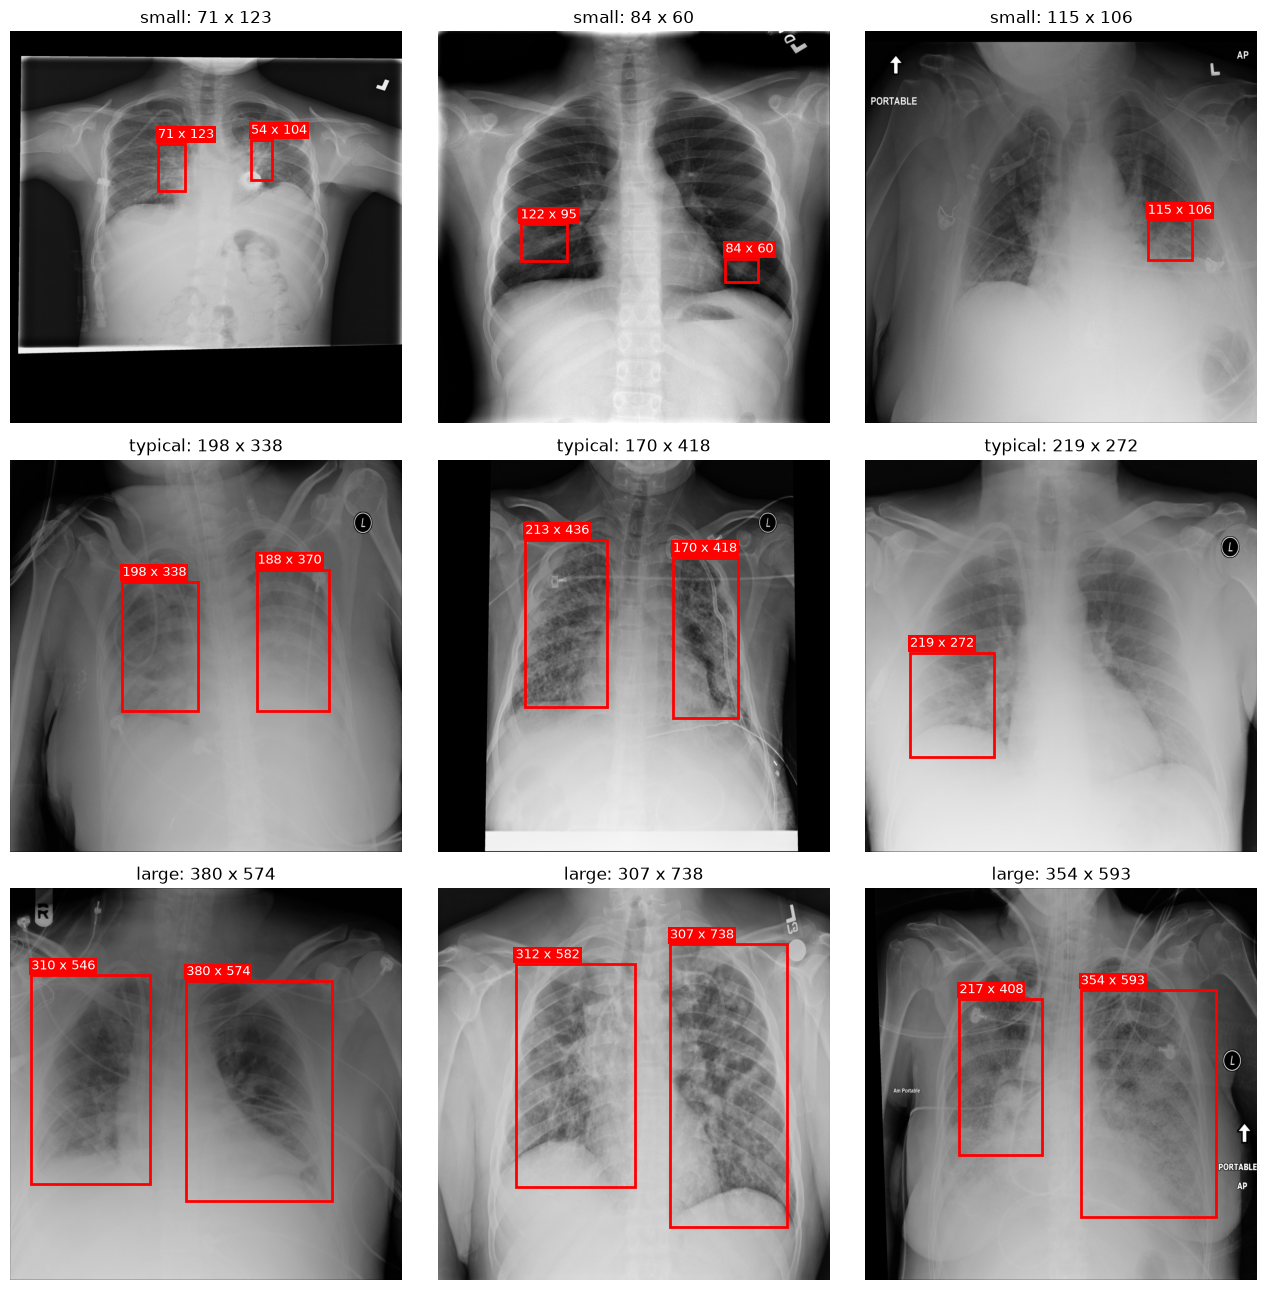

In [15]:
import pydicom
from matplotlib.patches import Rectangle

q05, q45, q55, q95 = boxes["area"].quantile([0.05, 0.45, 0.55, 0.95])
groups = {
    "small": boxes[boxes["area"] <= q05],
    "typical": boxes[boxes["area"].between(q45, q55)],
    "large": boxes[boxes["area"] >= q95],
}

fig, axes = plt.subplots(3, 3, figsize=(13, 13))
for row, (group, df) in zip(axes, groups.items()):
    for ax, box in zip(row, df.sample(3, random_state=0).itertuples()):
        img = pydicom.dcmread(DATA_DIR / "stage_2_train_images" / f"{box.patientId}.dcm").pixel_array
        ax.imshow(img, cmap="gray", vmin=0, vmax=255)
        for b in boxes[boxes["patientId"] == box.patientId].itertuples():
            ax.add_patch(Rectangle((b.x, b.y), b.width, b.height, fill=False, color="red", lw=2))
            ax.text(b.x, b.y - 8, f"{b.width:.0f} x {b.height:.0f}", color="white", fontsize=9, va="bottom",
                    bbox=dict(facecolor="red", edgecolor="none", pad=1.5))
        ax.set_title(f"{group}: {box.width:.0f} x {box.height:.0f}")
        ax.axis("off")
plt.tight_layout()
plt.show()

### 4.2 Box location

Left: how often each pixel is covered by a box. Right: box centers.

On a chest X-ray the patient's **right** lung is on the **left** side of the image.

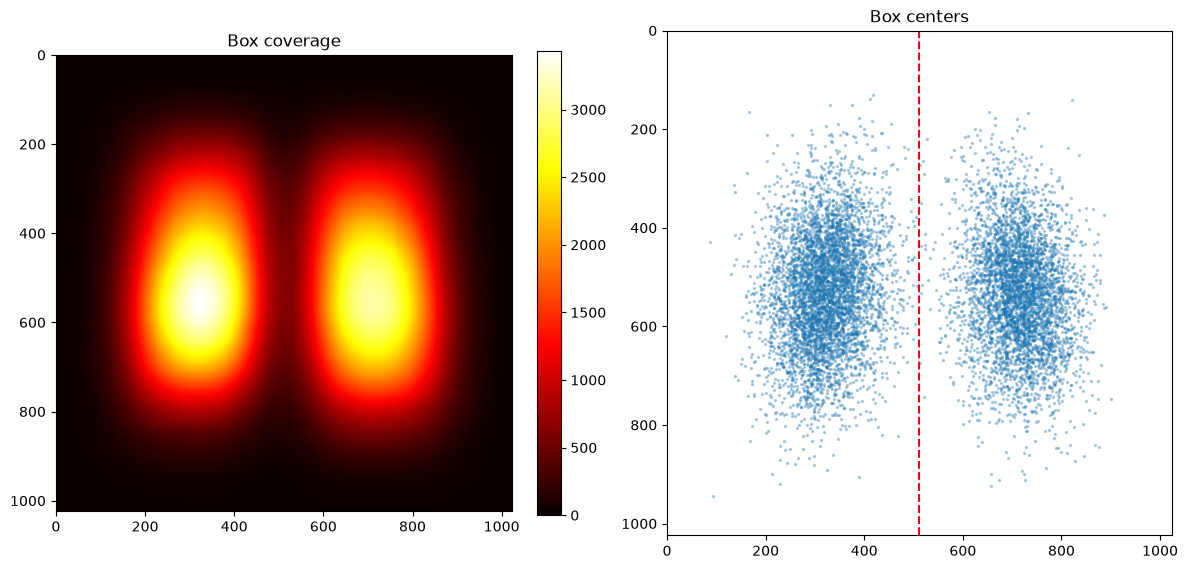

In [16]:
coverage = np.zeros((1024, 1024), dtype=np.int32)
for x, y, w, h in boxes[["x", "y", "width", "height"]].astype(int).itertuples(index=False):
    coverage[y:y + h, x:x + w] += 1

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
im = axes[0].imshow(coverage, cmap="hot")
axes[0].set_title("Box coverage")
fig.colorbar(im, ax=axes[0], fraction=0.046)

axes[1].scatter(boxes["cx"], boxes["cy"], s=2, alpha=0.3)
axes[1].set_xlim(0, 1024)
axes[1].set_ylim(1024, 0)
axes[1].set_aspect("equal")
axes[1].axvline(512, color="red", ls="--")
axes[1].set_title("Box centers")
plt.tight_layout()
plt.show()

### 4.3 Left vs right lung

A box is on the image-left side if its center is at `x < 512`. For patients with 2 boxes: are the two boxes in different lungs?

In [17]:
boxes["side"] = np.where(boxes["cx"] < 512, "image_left", "image_right")
display(boxes["side"].value_counts().to_frame("boxes"))

two_boxes = boxes.groupby("patientId").filter(lambda g: len(g) == 2)
sides = two_boxes.groupby("patientId")["side"].nunique().map({1: "same side", 2: "different sides"})
sides.value_counts().to_frame("patients with 2 boxes")

,boxes
side,
image_left,5114
image_right,4441


,patients with 2 boxes
side,
different sides,3196
same side,70


### 4.4 Key findings

- **This is not a small-object problem.** At 256 px input the median box is still 54 x 74 px and only 5% of boxes have a side below 27 px. 256–512 px inputs should be enough (the 1st place used 256–384).
- **Box size mostly follows how much of the lung is affected.** Large boxes cover almost a whole lung (diffuse disease), small ones mark a focal patch. Large boxes follow the lung outline rather than a sharp edge, so their exact borders are uncertain, which makes high IoU thresholds hard.
- Side note for the image section: images come with black borders, tilts, text markers (`PORTABLE`, `AP`, `L`), ECG leads and tubes.
- Boxes sit **only inside the two lungs**, mostly in the middle and lower parts. The center of the image (spine, heart) and the edges are almost never covered.
- Slightly more boxes on the image-left side (patient's right lung): 5,114 vs 4,441.
- Two boxes almost always means **one box per lung**: 3,196 of 3,266 patients (98%).

## 5. DICOM metadata

Each DICOM file has a header with information about the patient and the scan, next to the pixels.

### 5.1 Raw header

One file as it is (`stop_before_pixels=True` reads only the header, which is much faster).

In [18]:
pydicom.dcmread(DATA_DIR / "stage_2_train_images" / f"{labels.patientId[0]}.dcm", stop_before_pixels=True)

Dataset.file_meta -------------------------------
(0002,0000) File Meta Information Group Length  UL: 202
(0002,0001) File Meta Information Version       OB: b'\x00\x01'
(0002,0002) Media Storage SOP Class UID         UI: Secondary Capture Image Storage
(0002,0003) Media Storage SOP Instance UID      UI: 1.2.276.0.7230010.3.1.4.8323329.28530.1517874485.775526
(0002,0010) Transfer Syntax UID                 UI: JPEG Baseline (Process 1)
(0002,0012) Implementation Class UID            UI: 1.2.276.0.7230010.3.0.3.6.0
(0002,0013) Implementation Version Name         SH: 'OFFIS_DCMTK_360'
-------------------------------------------------
(0008,0005) Specific Character Set              CS: 'ISO_IR 100'
(0008,0016) SOP Class UID                       UI: Secondary Capture Image Storage
(0008,0018) SOP Instance UID                    UI: 1.2.276.0.7230010.3.1.4.8323329.28530.1517874485.775526
(0008,0020) Study Date                          DA: '19010101'
(0008,0030) Study Time                  

### 5.2 Which fields carry information?

Read the headers of all train and test files. A field with the same value in every file tells us nothing. The result is cached because reading ~30K headers takes a while.

In [19]:
from tqdm.auto import tqdm

FIELDS = ["PatientAge", "PatientSex", "ViewPosition", "Modality", "BodyPartExamined",
          "Rows", "Columns", "PixelSpacing", "BitsStored", "PhotometricInterpretation"]
CACHE = paths["processed_data_dir"] / "dicom_meta.csv"

if CACHE.exists():
    meta = pd.read_csv(CACHE)
else:
    records = []
    for split in ["train", "test"]:
        for f in tqdm(sorted((DATA_DIR / f"stage_2_{split}_images").iterdir()), desc=split):
            ds = pydicom.dcmread(f, stop_before_pixels=True)
            rec = {"patientId": f.stem, "split": split}
            rec.update({k: str(getattr(ds, k, "")) for k in FIELDS})
            records.append(rec)
    meta = pd.DataFrame(records)
    CACHE.parent.mkdir(parents=True, exist_ok=True)
    meta.to_csv(CACHE, index=False)

meta["PatientAge"] = meta["PatientAge"].astype(int)
pd.DataFrame({
    "n_unique": meta[FIELDS].nunique(),
    "values": [sorted(meta[c].unique().tolist())[:5] for c in FIELDS],
})

,n_unique,values
PatientAge,98,"[1, 2, 3, 4, 5]"
PatientSex,2,"[F, M]"
ViewPosition,2,"[AP, PA]"
Modality,1,[CR]
BodyPartExamined,1,[CHEST]
Rows,1,[1024]
Columns,1,[1024]
PixelSpacing,18,"[[0.115, 0.115], [0.139, 0.139], [0.1430000000..."
BitsStored,1,[8]
PhotometricInterpretation,1,[MONOCHROME2]


`PixelSpacing` is the physical size of one pixel in mm. The raw values carry float noise (`0.14300000000000002`), so we keep the first number rounded to 3 decimals:

In [20]:
meta["pixel_spacing"] = meta["PixelSpacing"].str.extract(r"\[([\d.]+)")[0].astype(float).round(3)
pd.crosstab(meta["pixel_spacing"], meta["split"])

split,test,train
pixel_spacing,,
0.115,2,8
0.139,607,5511
0.143,986,8993
0.168,1014,8815
0.171,225,1996
0.194,166,1358
0.199,0,3


### 5.3 Does metadata relate to the class?

**Question:** If age, sex or view position strongly predict the class, the classifier could use them as extra inputs (open question from the reference notes). Percentages are per row, so each row sums to 100.

In [21]:
train_meta = meta[meta["split"] == "train"].merge(patients.reset_index(), on="patientId")

for col in ["ViewPosition", "PatientSex"]:
    display((pd.crosstab(train_meta[col], train_meta["class"], normalize="index") * 100).round(1)
            .assign(n_patients=train_meta[col].value_counts()))

class,Lung Opacity,No Lung Opacity / Not Normal,Normal,n_patients
ViewPosition,,,,
AP,38.3,48.2,13.4,12173
PA,9.3,41.0,49.7,14511


class,Lung Opacity,No Lung Opacity / Not Normal,Normal,n_patients
PatientSex,,,,
F,21.7,44.4,33.9,11518
M,23.1,44.2,32.6,15166


Pixel spacing depends on the X-ray machine. Class shares and the share of AP images per spacing:

In [22]:
(pd.crosstab(train_meta["pixel_spacing"], train_meta["class"], normalize="index") * 100).round(1).assign(
    pct_AP=(train_meta.groupby("pixel_spacing")["ViewPosition"].apply(lambda s: (s == "AP").mean()) * 100).round(1),
    n_patients=train_meta["pixel_spacing"].value_counts(),
)

class,Lung Opacity,No Lung Opacity / Not Normal,Normal,pct_AP,n_patients
pixel_spacing,,,,,
0.115,25.0,37.5,37.5,62.5,8
0.139,31.7,46.5,21.7,80.2,5511
0.143,8.4,41.6,49.9,0.0,8993
0.168,32.4,45.8,21.8,75.5,8815
0.171,27.6,45.1,27.4,54.3,1996
0.194,7.1,42.0,50.9,0.3,1358
0.199,66.7,33.3,0.0,100.0,3


Does pixel spacing tell us anything beyond the view? Lung Opacity share (%) per spacing, within each view:

In [23]:
train_meta.pivot_table(index="pixel_spacing", columns="ViewPosition", values="Target",
                       aggfunc=[lambda s: round(s.mean() * 100, 1), "size"]).set_axis(
    ["pct_LO_AP", "pct_LO_PA", "n_AP", "n_PA"], axis=1)

,pct_LO_AP,pct_LO_PA,n_AP,n_PA
pixel_spacing,,,,
0.115,40.0,0.0,5.0,3.0
0.139,37.4,9.0,4420.0,1091.0
0.143,0.0,8.4,1.0,8992.0
0.168,38.8,12.7,6657.0,2158.0
0.171,39.5,13.4,1083.0,913.0
0.194,0.0,7.1,4.0,1354.0
0.199,66.7,NaN,3.0,NaN


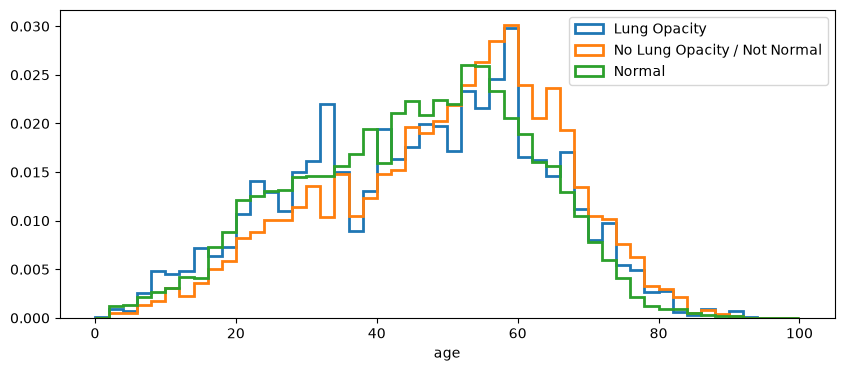

,split,PatientAge
4115,train,148
24374,train,150
10648,train,151
16213,train,153
25537,train,155
28218,test,412


In [24]:
fig, ax = plt.subplots(figsize=(10, 4))
for cls, df in train_meta[train_meta["PatientAge"] <= 100].groupby("class"):
    ax.hist(df["PatientAge"], bins=range(0, 101, 2), histtype="step", lw=2, density=True, label=cls)
ax.set_xlabel("age")
ax.legend()
plt.show()

meta.loc[meta["PatientAge"] > 100, ["split", "PatientAge"]].sort_values("PatientAge")

### 5.4 Is the test set like the train set?

**Question:** If the test images came from a different population, validation scores on train would be misleading.

In [25]:
for col in ["ViewPosition", "PatientSex"]:
    display((pd.crosstab(meta["split"], meta[col], normalize="index") * 100).round(1))

meta.groupby("split")["PatientAge"].describe().round(1)

ViewPosition,AP,PA
split,,
test,46.1,53.9
train,45.6,54.4


PatientSex,F,M
split,,
test,42.9,57.1
train,43.2,56.8


,count,mean,std,min,25%,50%,75%,max
split,,,,,,,,
test,3000.0,47.1,18.2,1.0,34.0,49.0,59.0,412.0
train,26684.0,47.0,16.8,1.0,34.0,49.0,59.0,155.0


### 5.5 Key findings

- Only **age, sex, view position and pixel spacing** carry information. The images are all 1024 x 1024, 8-bit, `MONOCHROME2` chest X-rays; dates and names are anonymized.
- The organizers already reduced the original images (> 2000 px, high bit depth) to 1024 px and 8 bits and applied windowing, so we do not need to window them again. The dataset is also enriched: it has far more pneumonia cases than real life.
- **View position is a strong signal.** Lung Opacity is 38% of AP images but only 9% of PA images. AP images are usually taken at the bedside of patients too sick to stand, so this reflects who gets which scan. The model can also see the view in the image itself (the `PORTABLE` / `AP` markers), so it may learn it as a shortcut.
- **Pixel spacing most likely marks the X-ray machine type**, and it is tied to the view: 0.143 and 0.194 mm are almost only PA, 0.139 and 0.168 mm mostly AP. Within a view it adds little: AP images have 37–40% Lung Opacity at every spacing, PA images 7–13%. Across the main machines one pixel is 0.139–0.194 mm, so the same box in pixels can be ~40% larger in reality.
- **Sex and age barely matter.** The class shares are almost the same for F and M, and the age distributions of the three classes overlap.
- **Age has errors:** 6 patients are older than 100 (5 in train with 148–155, 1 in test with 412). Clip or ignore them if age is ever used.
- **Train and test look alike** in view, sex, age and pixel spacing, so metadata gives no sign of a distribution shift.

For more reliable results later:

- Keep the AP/PA ratio the same in every validation fold, so no fold is easier than the others.

## 6. Images

### 6.1 What does each class look like?

**Question:** Can we see the difference between the classes by eye, especially between Lung Opacity and Not Normal? 4 random patients per class, boxes in red.

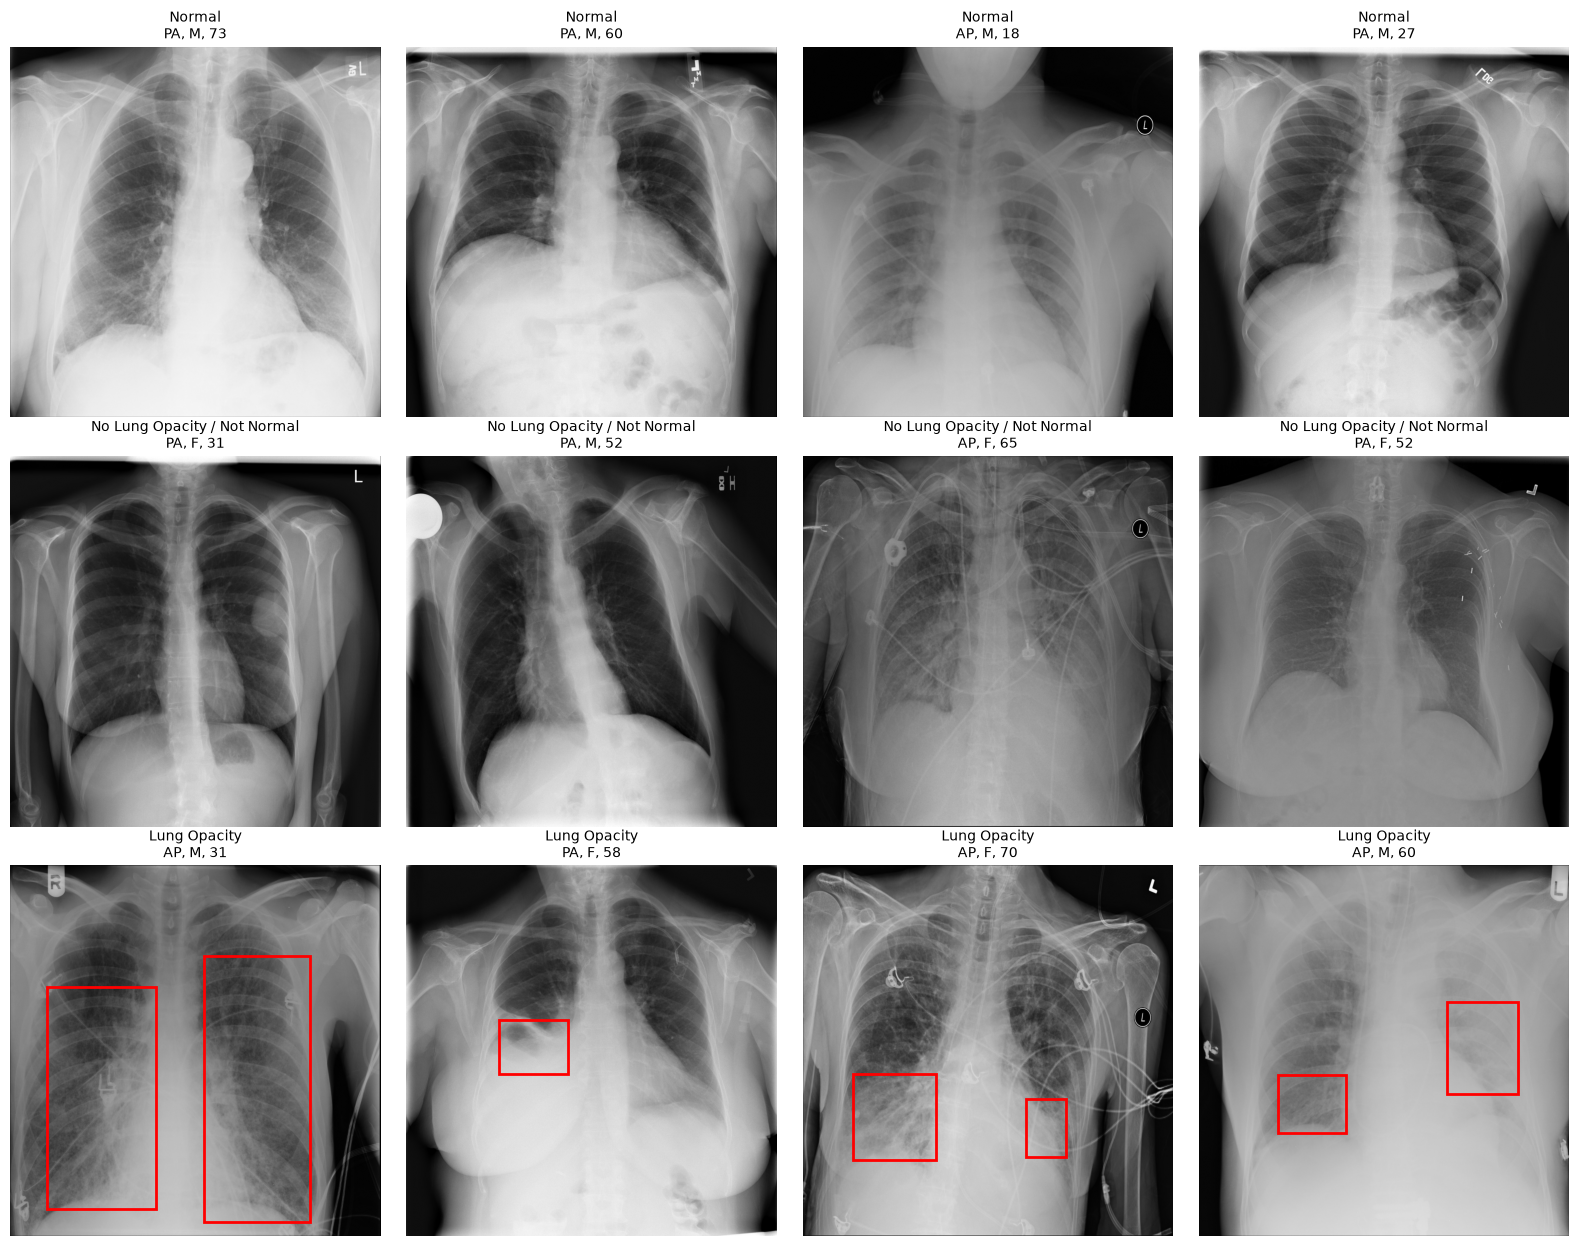

In [26]:
def load_image(pid, split="train"):
    return pydicom.dcmread(DATA_DIR / f"stage_2_{split}_images" / f"{pid}.dcm").pixel_array


def show_patient(ax, pid, title=""):
    ax.imshow(load_image(pid), cmap="gray", vmin=0, vmax=255)
    for b in boxes[boxes["patientId"] == pid].itertuples():
        ax.add_patch(Rectangle((b.x, b.y), b.width, b.height, fill=False, color="red", lw=2))
    ax.set_title(title, fontsize=10)
    ax.axis("off")


class_order = ["Normal", "No Lung Opacity / Not Normal", "Lung Opacity"]
fig, axes = plt.subplots(3, 4, figsize=(16, 12.5))
for row, cls in zip(axes, class_order):
    sample = train_meta[train_meta["class"] == cls].sample(4, random_state=1)
    for ax, p in zip(row, sample.itertuples()):
        show_patient(ax, p.patientId, f"{cls}\n{p.ViewPosition}, {p.PatientSex}, {p.PatientAge}")
plt.tight_layout()
plt.show()

### 6.2 Brightness and contrast

**Question:** Do images differ so much in brightness and contrast that we must normalize them? Mean (brightness) and standard deviation (contrast) of the pixel values for 5,000 random train images.

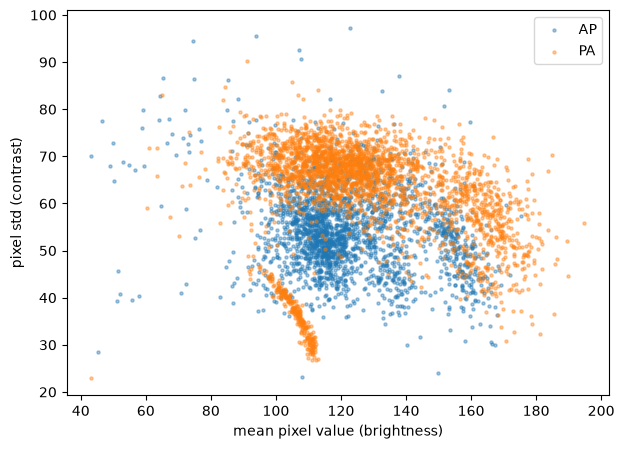

ViewPosition      AP      PA
mean count    2266.0  2734.0
     mean      122.0   126.8
     std        19.1    23.2
     min        43.3    43.2
     25%       110.9   109.4
     50%       118.6   122.2
     75%       133.1   140.8
     max       175.3   194.9
std  count    2266.0  2734.0
     mean       54.3    62.1
     std         8.8    11.1
     min        23.1    23.0
     25%        48.6    58.5
     50%        53.9    65.6
     75%        59.6    69.5
     max        97.2    90.2

In [27]:
img_sample = train_meta.sample(5000, random_state=0).copy()
stats = [(img.mean(), img.std()) for img in (load_image(pid) for pid in tqdm(img_sample["patientId"]))]
img_sample[["mean", "std"]] = stats

fig, ax = plt.subplots(figsize=(7, 5))
for view, df in img_sample.groupby("ViewPosition"):
    ax.scatter(df["mean"], df["std"], s=5, alpha=0.4, label=view)
ax.set_xlabel("mean pixel value (brightness)")
ax.set_ylabel("pixel std (contrast)")
ax.legend()
plt.show()

img_sample.groupby("ViewPosition")[["mean", "std"]].describe().round(1).T

The extremes: darkest, brightest, lowest and highest contrast.

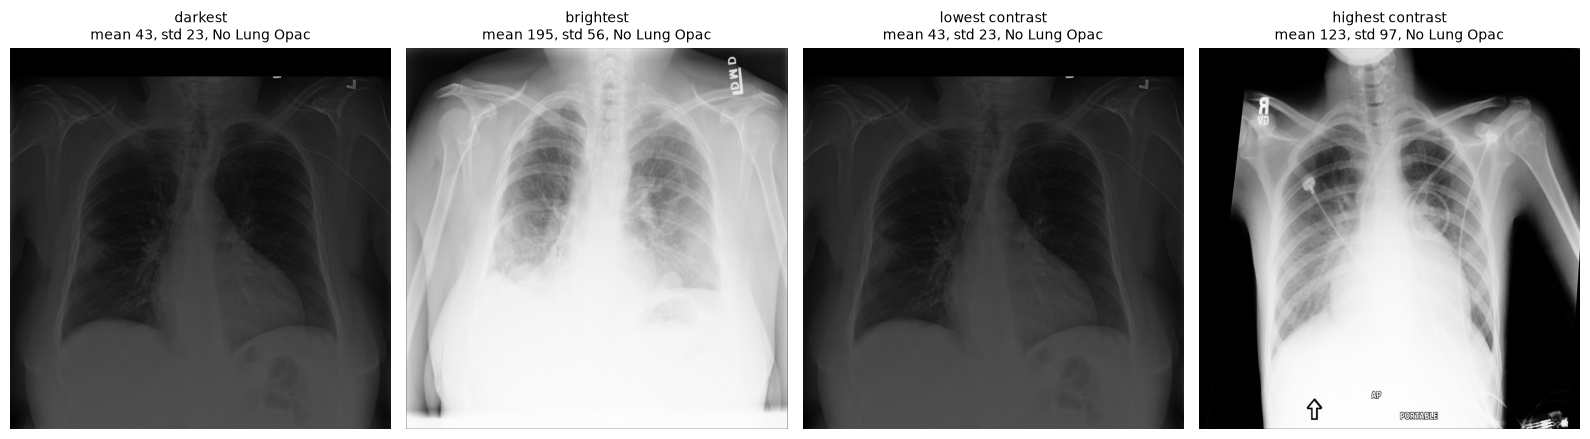

In [28]:
extremes = {
    "darkest": img_sample.nsmallest(1, "mean"),
    "brightest": img_sample.nlargest(1, "mean"),
    "lowest contrast": img_sample.nsmallest(1, "std"),
    "highest contrast": img_sample.nlargest(1, "std"),
}
fig, axes = plt.subplots(1, 4, figsize=(16, 4.5))
for ax, (name, df) in zip(axes, extremes.items()):
    r = df.iloc[0]
    show_patient(ax, r.patientId, f"{name}\nmean {r['mean']:.0f}, std {r['std']:.0f}, {r['class'][:12]}")
plt.tight_layout()
plt.show()

**Question:** Where does the grey, washed-out group of PA images (bottom left of the scatter plot) come from? We select it by eye from the plot (PA, std < 45, mean 95–120) and compare it with the pixel spacing.

In [29]:
washed_out = (img_sample["ViewPosition"] == "PA") & (img_sample["std"] < 45) & img_sample["mean"].between(95, 120)
pd.crosstab(img_sample["pixel_spacing"], washed_out.rename("washed_out"))

washed_out,False,True
pixel_spacing,,
0.115,2,0
0.139,1060,1
0.143,1683,0
0.168,1645,0
0.171,357,0
0.194,11,240
0.199,1,0


### 6.3 CLAHE

**Question:** CLAHE (Contrast Limited Adaptive Histogram Equalization) boosts contrast locally, tile by tile, and was used by the 4th place. Does it make opacities easier to see and fix the washed-out images? Top: original, bottom: CLAHE. The first image is the darkest one from 6.2, the others are Lung Opacity.

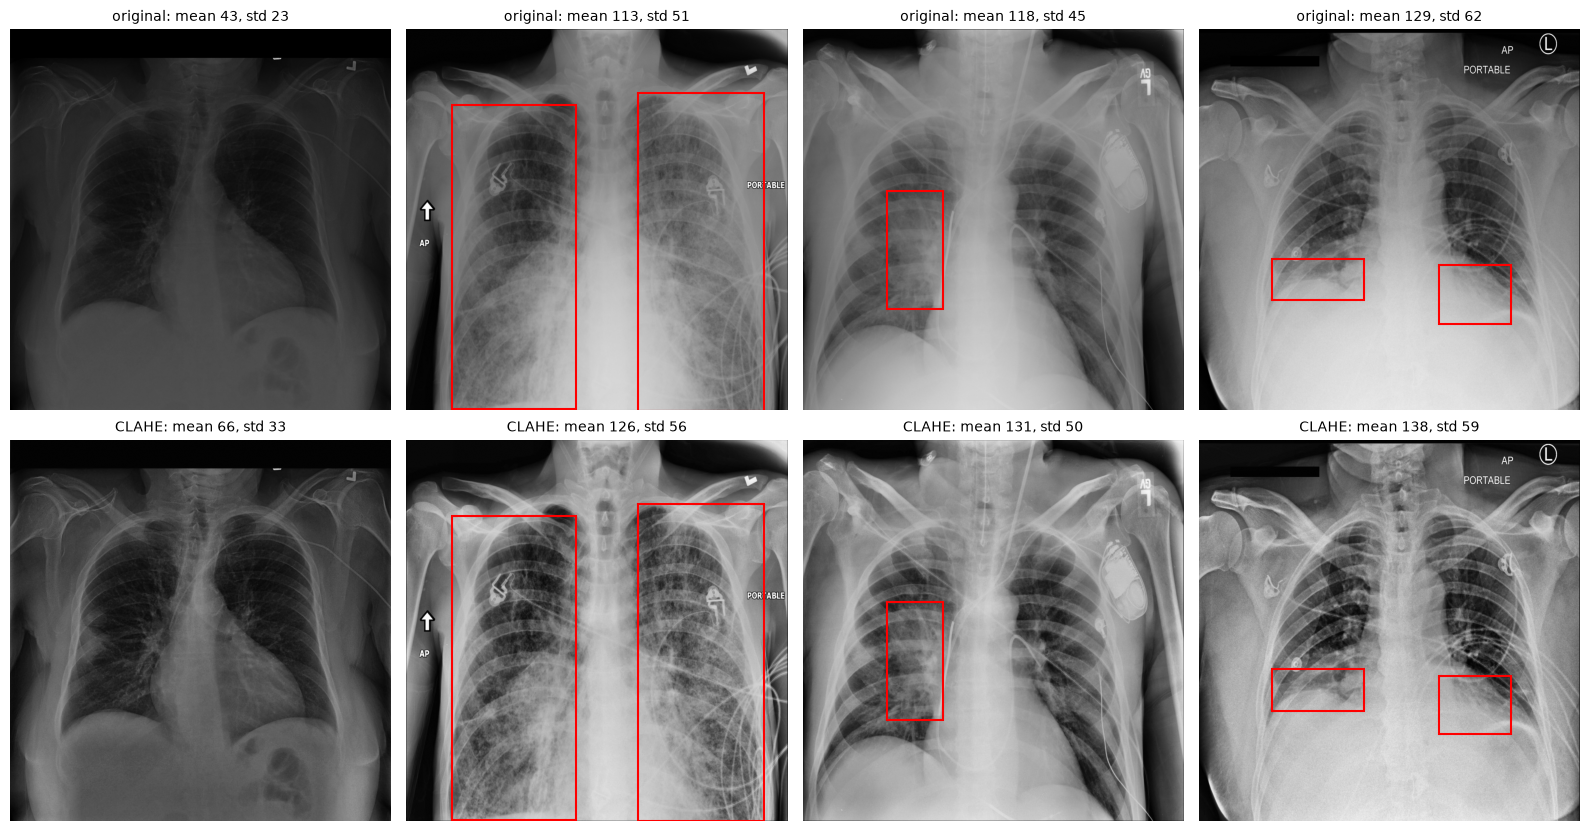

In [30]:
import cv2

clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

pids = [extremes["darkest"].iloc[0].patientId]
pids += train_meta[train_meta["class"] == "Lung Opacity"].sample(3, random_state=2)["patientId"].tolist()

fig, axes = plt.subplots(2, 4, figsize=(16, 8.5))
for col, pid in enumerate(pids):
    img = load_image(pid)
    for row, (name, im) in enumerate([("original", img), ("CLAHE", clahe.apply(img))]):
        ax = axes[row, col]
        ax.imshow(im, cmap="gray", vmin=0, vmax=255)
        for b in boxes[boxes["patientId"] == pid].itertuples():
            ax.add_patch(Rectangle((b.x, b.y), b.width, b.height, fill=False, color="red", lw=1.5))
        ax.set_title(f"{name}: mean {im.mean():.0f}, std {im.std():.0f}", fontsize=10)
        ax.axis("off")
plt.tight_layout()
plt.show()

### 6.4 Key findings

- **Lung Opacity** is a hazy white area that hides the normal lung pattern. The difference to **Not Normal** is often subtle for an untrained eye: both contain wires, tubes and other findings.
- AP images look different as a whole: the patient is lying, the image is less sharp and there are more wires and ECG leads. This supports the shortcut risk from section 5.
- **Brightness and contrast vary a lot** between images (mean 43–195, std 23–97). AP images have lower contrast than PA. A separate group of PA images is grey and washed out (low std). It most likely comes from one machine type: 240 of the 241 images in this group have a pixel spacing of 0.194 mm.
- The highest "contrast" is a tilted image with large black borders, so the std also measures borders, not only the lungs.
- **CLAHE** makes the lung texture, vessels and the edges of opacities clearer and lifts the washed-out image. It does not fully equalize brightness (the dark image stays darker) and it also sharpens wires and noise.

For more reliable results later:

- We can use brightness/contrast, small rotation and shift augmentations, because the data already contains this variety.
- We can treat CLAHE as an experiment: train the same model with and without it. Easier to see for us does not always mean better for a CNN.